In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [70]:
data = pd.read_csv('/Users/mac/Downloads/Spherical_galaxy.dat',header=None,sep=' ')
data.columns = ['x','y','z','vx','vy','vz']
cols = data.columns
data

,x,y,z,vx,vy,vz
0,0.025827,8.080713,-2.964450,-31.729433,58.914085,-38.310940
1,-1.275629,2.734614,0.053139,19.549257,30.629965,-6.506386
2,15.332361,4.224397,-15.025769,54.239281,-15.984748,21.306578
3,-5.702172,6.756396,-7.549031,-65.450752,25.626844,9.740432
4,16.160419,-5.821236,4.720833,-22.776388,65.532310,-1.868893
...,...,...,...,...,...,...
199995,-100.960793,-10.359862,73.410027,-6.398535,5.650262,16.406597
199996,-1.361795,6.515509,-1.782245,10.997408,-10.678014,-2.133975
199997,6.171734,0.643587,4.321414,40.191097,20.053066,-10.087251
199998,-5.110960,-14.092740,-0.920155,37.292534,19.064760,-2.376553


# Distribución espacial

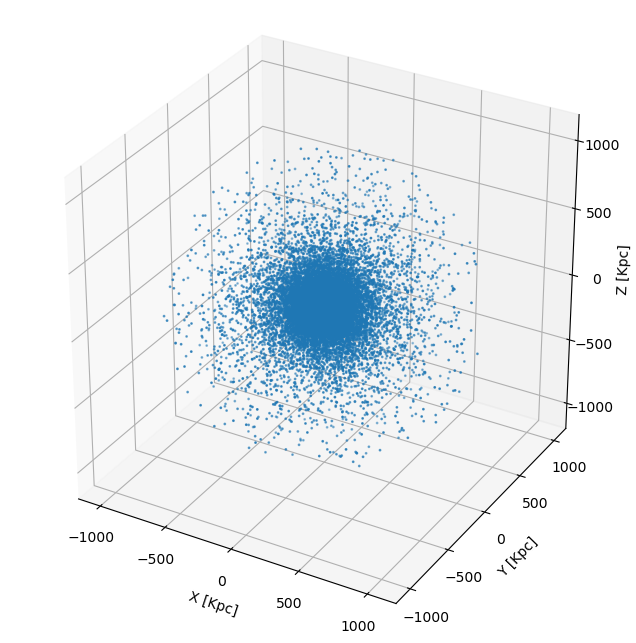

In [267]:
# Crear la figura y los ejes en 3D
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos en 3D
ax.scatter(data.x, data.y, data.z,s=1)

# Etiquetas de los ejes
ax.set_xlabel('X [Kpc]')
ax.set_ylabel('Y [Kpc]')
ax.set_zlabel('Z [Kpc]')

ax.set_box_aspect([1, 1, 1])  # Aspect ratio de 1:1:1

# Mostrar el gráfico
plt.show()

# a) anisotropía 

$$\sigma^2 = \overline{v_xv_x} - \overline{v_x} .\overline{v_x}$$

In [247]:
def cov(data,x,y):
    return np.mean(data[x]*data[y]) - np.mean(data[x])*np.mean(data[y])

In [110]:
td = np.ones([3,3])

for i in range(3):
    for j in range(3):
        td[i,j] = cov(data,cols[i+3],cols[j+3])
        
td

array([[ 1.12119804e+03, -2.33955972e+00, -2.36914191e+00],
       [-2.33955972e+00,  1.11176534e+03, -2.45999930e-01],
       [-2.36914191e+00, -2.45999930e-01,  1.12246852e+03]])

Matriz de correlación

$$corr(x,y) = \frac{COV(x,x)}{\sigma_x \sigma_x}$$

In [111]:
corr = np.ones([3,3])


for i in range(3):
    for j in range(3):
        corr[i,j] = cov(data,cols[i+3],cols[j+3])/(np.std(data[cols[j+3]])*np.std(data[cols[j+3]]))

corr

array([[ 1.00000000e+00, -2.10436468e-03, -2.11065333e-03],
       [-2.08666055e-03,  1.00000000e+00, -2.19159759e-04],
       [-2.11304500e-03, -2.21269652e-04,  1.00000000e+00]])

In [129]:
# Número de muestras bootstrap
n_bootstrap = 10000

# Almacena las medias de cada muestra bootstrap
bootstrap_means = []

for i in tqd(range(n_bootstrap)):
    
    data_bst = pd.DataFrame()
    
    data_bst['vx'] = np.random.choice(data.vx, size=len(data), replace=True)
    data_bst['vy'] = np.random.choice(data.vy, size=len(data), replace=True)
    data_bst['vz'] = np.random.choice(data.vz, size=len(data), replace=True)
    
    
    corr_bst = np.ones([3,3])

    for i in range(3):
        for j in range(3):
            corr_bst[i,j] = cov(data_bst,cols[i+3],cols[j+3])/(np.std(data_bst[cols[j+3]])*np.std(data_bst[cols[j+3]]))

    bootstrap_means.append(corr_bst)
    
bootstrap_means = np.array(bootstrap_means)
#means = np.mean(bootstrap_means,axis=0)

In [156]:
# Intervalo de confianza del 95%

conf_interval_5 = np.ones([3,3])
conf_interval_95 = np.ones([3,3])

for i in range(3):
    for j in range(3):
        conf_interval_5[i,j] = np.percentile(bootstrap_means[:,i,j], 5)
        conf_interval_95[i,j] = np.percentile(bootstrap_means[:,i,j], 95)

In [157]:
conf_interval_5

array([[ 1.        , -0.00370273, -0.00366671],
       [-0.00366857,  1.        , -0.00369532],
       [-0.00366716, -0.00372543,  1.        ]])

In [158]:
conf_interval_95

array([[1.        , 0.00373194, 0.00370288],
       [0.00370616, 1.        , 0.00372272],
       [0.00370085, 0.00375452, 1.        ]])

# Equilibrio estacionario

In [165]:
es = np.ones([3,3])

for i in range(3):
    for j in range(3):
        es[i,j] =  np.mean(data[cols[i+3]])*np.mean(data[cols[j+3]])
        
es

array([[ 5.88062487e-18,  5.52899988e-18, -1.09973749e-17],
       [ 5.52899988e-18,  5.19839989e-18, -1.03397999e-17],
       [-1.09973749e-17, -1.03397999e-17,  2.05662249e-17]])

# Dispersión de velocidades como función del radio

In [379]:
# coordenada radial
data['r'] = np.sqrt(data.x**2+data.y**2+data.z**2)

# Velocidad radial
data['vr'] = np.sqrt(data.vx**2+data.vy**2+data.vz**2)

r = np.linspace(0,max(data.r),200)

sigmas = []
rho = []

for i in range(len(r)-1):
    cascaron = data[(data.r > r[i]) & (data.r <= r[i+1])]
    rho.append(len(cascaron)/(4/3*np.pi*(r[i+1]**3-r[i]**3)))
    sigmas.append(cov(cascaron,'vr','vr'))

sigmas = np.array(sigmas)
rho = np.array(rho)

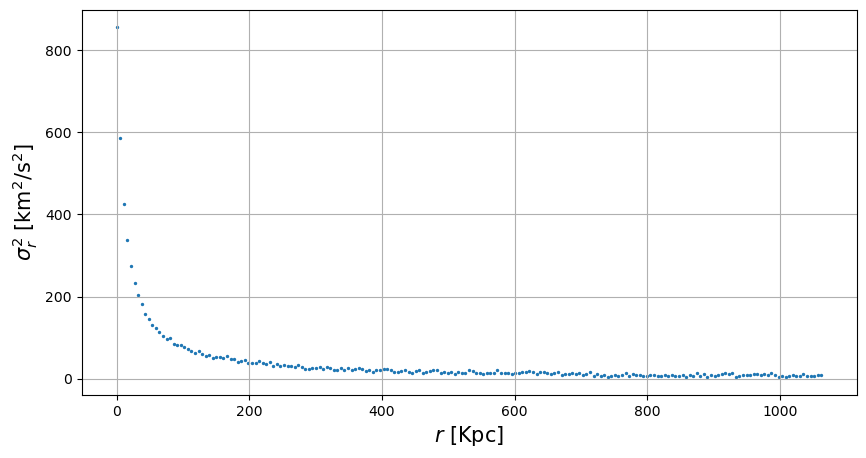

In [380]:
plt.figure(figsize=(10,5))
plt.scatter(r[:-1],sigmas,s=2)
plt.ylabel('$\sigma_r^2$ [km$^2$/s$^2$]',fontsize=15)
plt.xlabel('$r$ [Kpc]',fontsize=15)

plt.grid()

# Masa total del sistema

$$M(r) = - \frac{r\sigma^2}{G}\left[\sigma^2 \frac{d\ln\rho}{d\ln{ r}}  +\rho \frac{d\ln \sigma^2}{d \ln {r}} + 2\beta \right]$$

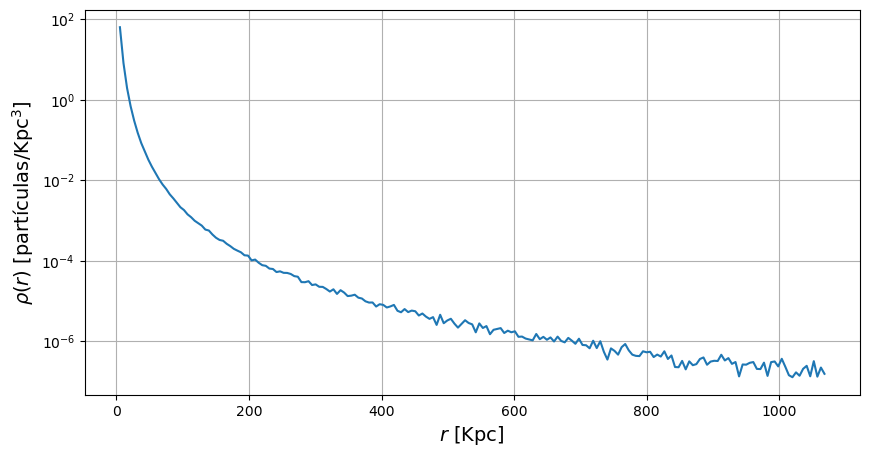

In [381]:
# Perfil de densidad

plt.figure(figsize=(10,5))
plt.plot(r[1:],rho)
#plt.xscale('log')
plt.yscale('log')
plt.xlabel('$r$ [Kpc]',fontsize=14)
plt.ylabel(r'$\rho(r)$ [partículas/Kpc$^3$]',fontsize=14)
plt.grid()

In [400]:
drhodr = np.gradient(np.log(rho), np.log(r[1:]))
dsigmadr = np.gradient(np.log(sigmas),np.log(r[1:]))

G = 43007.1
M = abs(r[1:]*sigmas/G*(sigmas*drhodr + rho*dsigmadr))

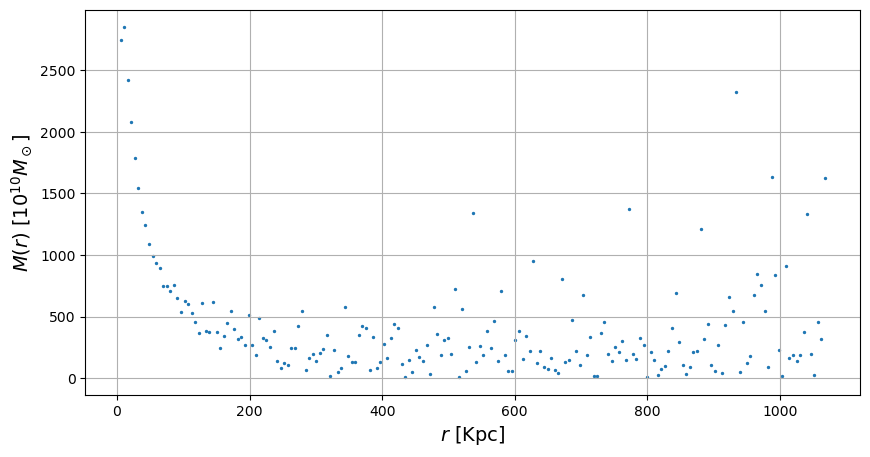

In [402]:
plt.figure(figsize=(10,5))
plt.scatter(r[1:],M*10,s=2)
plt.xlabel('$r$ [Kpc]',fontsize=14)
plt.ylabel(r'$M(r)$ [$10^{10} M_\odot$]',fontsize=14)
plt.grid()

In [404]:
# Masa total
MT = np.trapz(M*10, r[1:])
MT 

438635.8833362014

In [364]:
from scipy.optimize import curve_fit

/var/folders/8b/0cwkk0093nvclpmknxlmlcl80000gn/T/ipykernel_38915/1435005066.py:3: RuntimeWarning: overflow encountered in exp
  return a * np.exp(b * x)


(0.0, 300.0)

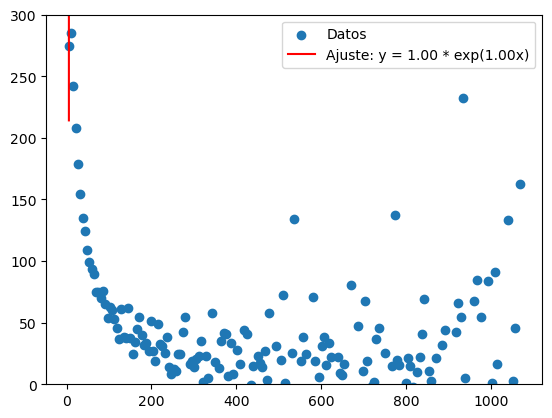

In [385]:
# Definir la función exponencial a ajustar
def exp_func(x, a, b):
    return a * np.exp(b * x)

x = r[1:]
y = M

# Ajustar la función a los datos
params, covariance = curve_fit(exp_func, x, y)

# Parámetros ajustados
a, b = params

# Graficar los datos y la función ajustada
plt.scatter(x, y, label='Datos')
plt.plot(x, exp_func(x, a, b), label=f'Ajuste: y = {a:.2f} * exp({b:.2f}x)', color='red')
plt.legend()
plt.ylim(0,300)